## Essay Evaluator Parallel Workflow using LLMs

Here, the goal is to evaluate the essay using LLMs wrt 3 different parameters parallely and generate 3 scores, Now the final node which combines these 3 scores and generates an average score and a summary feedback text and give it to the user.

Now, the 3 aspects of judging the summary are:
1. Clarity of Thought (COT)
2. Depth of Analysis (DOA)
3. Language Quality (LQ) ( Using proper language or not, like tone etc etc )

Each of these parameters are a number between 0 to 10.

### Challenges

1. How will we ensure that the LLM nodes will generate a feedback number exactly between 0 and 10 and also a textual feedback along with it --> THIS WILL BE TAKEN CARE OF BY STRUCTURED OUTPUT CONCEPT FROM LANGCHAIN.

2. Here, as 3 LLMs will generate 3 summaries and 3 scores, we will store the summaries in their individual keys, Now, as the scores will have same 'keys' or names , we cannot store them in a single state variable, because each time nodes return them, they will overridden in the state, for this we need to store the scores in a list of 3 elements and then store them in seperate key called 'individual_scores' in the state. But the problem is before storing to the state, we need to make those values returned by the individual nodes in to a list and then store them right, so modifcation of data is happening by merging the values, for doing this we will a concept called REDUCER component of langgraph.

### Lets start

Now first lets import all the essential modules


In [13]:
from langgraph.graph import StateGraph, START, END 
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

Lets define the model (make sure it supports structured output)

In [4]:
model = ChatOpenAI(model = 'gpt-4o-mini')

Lets define the schema for structured output

In [2]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the essay')
    #for score we are even giving it the range also
    score: int = Field(description='Score out of 10', ge=0, le=10)

Now, create a model which gives structured output by adding schema to the existing model

In [5]:
structured_model = model.with_structured_output(EvaluationSchema)

Lets test this model with a sample essay

In [6]:
essay = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.
"""

Now, lets make a simple prompt and invoke the model

In [9]:
prompt = f"Evaluate the language quality of the essay and provide a feedback and assign a score out of 10 \n {essay}"

st_output = structured_model.invoke(prompt)

st_output

EvaluationSchema(feedback="The essay presents a well-structured analysis of India's position in the age of AI, highlighting both its strengths and challenges. The introduction effectively sets the stage by emphasizing the importance of AI in shaping India's future. The use of relevant statistics, such as the number of STEM graduates and insights into specific sectors like agriculture and healthcare, contributes to the argument and enhances credibility. \n\nEach paragraph transitions smoothly, maintaining a logical flow that connects ideas seamlessly. The essay also addresses potential challenges, such as the digital divide and data privacy, which reflects a balanced perspective. Additionally, the conclusion succinctly summarizes the main points and provides a forward-looking vision for responsible AI integration.\n\nHowever, the essay could benefit from more personal or anecdotal evidence to illustrate its points vividly. Additionally, some areas could use more nuanced discussion about

We are getting feddback and score both

In [10]:
st_output.feedback

"The essay presents a well-structured analysis of India's position in the age of AI, highlighting both its strengths and challenges. The introduction effectively sets the stage by emphasizing the importance of AI in shaping India's future. The use of relevant statistics, such as the number of STEM graduates and insights into specific sectors like agriculture and healthcare, contributes to the argument and enhances credibility. \n\nEach paragraph transitions smoothly, maintaining a logical flow that connects ideas seamlessly. The essay also addresses potential challenges, such as the digital divide and data privacy, which reflects a balanced perspective. Additionally, the conclusion succinctly summarizes the main points and provides a forward-looking vision for responsible AI integration.\n\nHowever, the essay could benefit from more personal or anecdotal evidence to illustrate its points vividly. Additionally, some areas could use more nuanced discussion about the implications of AI be

In [11]:
st_output.score

8

Now, that we have a model which supports structured output, challenge 1 is completed, lets go to building our paralle workflow.

In [17]:
class EssayState(TypedDict):

    #Add the input variable to the state
    essay: str

    #Lets add the feedbacks from 3 LLM evaluator nodes
    language_feedback : str
    depth_analysis_feedback: str
    thought_clarity_feedback: str

    #Lets define the attributes for 3rd LLM node which will summarize the above feebacks
    overall_feedback: str

    #Finally as we have discussed we will use a list of integers to combine 3 scores
    #We will not simply define like shown below, its a little complex
    #individual_scores: list[int]

    # We will use the concept of reducers here, whose job is to inform the state dict, what to do to a particular key
    # its job is to tell, whether to add values to this key, delete or just override etc
    # We will use python's operator module to define this job task, so that Graph will know, what to do with this variable

    individual_scores : Annotated[list[int], operator.add]
    #Here inside annotated, first is the datatype and 2nd is the task which will happen on that
    #Here this 'add' function is itself called reducer function.
    
    #average_score which will also be computed by the final node
    average_score: str

We will use the concept of reducers here, whose job is to inform the state dict, what to do to a particular key.
* its job is to tell, whether to add values to this key, delete or just override etc
* We will use python's operator module to define this job task, so that Graph will know, what to do with this variable
```
    individual_scores : Annotated[list[int], operator.add]
```
Here inside annotated, first is the datatype and 2nd is the task which will happen on that

Here this 'add' function is itself called reducer function.

HERE, NOTE that operator.add will simply add the values:

for example: if we give, 2 and 3 parallely to it, it will add them and store 6

But if we give [2] and [3] as lists, it will add the lists which means it will become [2,3], we are taking advantage of this stuff and creating a list of individual scores

In [15]:
[2]+ [3] #Hence proved

[2, 3]

Lets define the functions to be used as nodes 

In [22]:
#Lets define language evaluator node
def evaluate_language(state: EssayState):

    #Lets get the essay from the state and pass it the LLM
    essay = state['essay']

    #Lets put it into the prompt
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

    #get the output from the model which contains feedback and score
    st_output = structured_model.invoke(prompt)

    #Lets follow partial state update here, notice that we are putting score in a list
    return {'language_feedback': st_output.feedback, 'individual_scores': [st_output.score]}

#lets define the depth analysis node
def evaluate_depth(state: EssayState):

    #Lets get the essay from the state and pass it the LLM
    essay = state['essay']

    #Lets put it into the prompt
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

    #get the output from the model which contains feedback and score
    st_output = structured_model.invoke(prompt)

    #Lets follow partial state update here, notice that we are putting score in a list
    return {'depth_analysis_feedback': st_output.feedback, 'individual_scores': [st_output.score]}

#Lets define the clarity of thought evaluator node
def evaluate_thought_clarity(state: EssayState):

    #Lets get the essay from the state and pass it the LLM
    essay = state['essay']

    #Lets put it into the prompt
    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}'

    #get the output from the model which contains feedback and score
    st_output = structured_model.invoke(prompt)

    #Lets follow partial state update here, notice that we are putting score in a list
    return {'thought_clarity_feedback': st_output.feedback, 'individual_scores': [st_output.score]}

#Lets define the final node for overall evaluation
def final_evaluation(state: EssayState):

    #For getting the Summary feedback from 3 feedback , lets define a prompt
    prompt = f""" 
    Based on the following feedbacks create a summarized feedback:
        language feedback - {state['language_feedback']}
        depth of analysis feedback - {state['depth_analysis_feedback']}
        clarity of thought feedback - {state['thought_clarity_feedback']} 
    """

    #here we donot need json output right, so we can use normal model only
    overall_feedback = model.invoke(prompt)
    
    #Calculate the Average from all the individual scores 
    average_score= sum(state['individual_scores']) / len(state['individual_scores'])

    #as usual use the partial state update
    return {'overall_feedback': overall_feedback, 'average_score': average_score }


Now lets create the graph

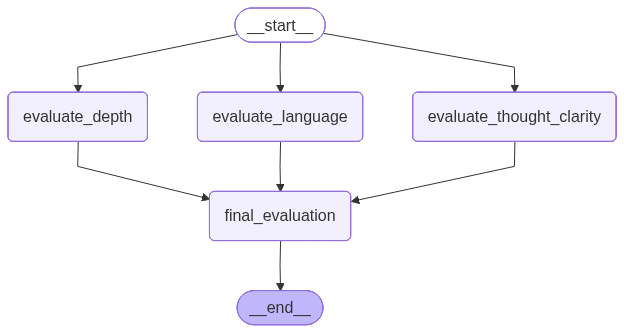

In [23]:
graph =StateGraph(EssayState)

#Lets add the parallel nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_depth', evaluate_depth)
graph.add_node('evaluate_thought_clarity', evaluate_thought_clarity)

#Add the final node
graph.add_node('final_evaluation', final_evaluation)

#Now lets add the parallel edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_depth')
graph.add_edge(START, 'evaluate_thought_clarity')

#connect the parallel node to the final nodes with 3 more edges
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_depth', 'final_evaluation')
graph.add_edge('evaluate_thought_clarity', 'final_evaluation')

#Connect the final node to the end node
graph.add_edge('final_evaluation', END)

#Lets compile the graph
workflow = graph.compile()

#Lets visualize it
workflow


Now, lets run the graph

In [24]:
initial_state = {
    'essay': essay
}

final_state = workflow.invoke(initial_state)

final_state

{'essay': "India in the Age of AI\nAs the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.\n\nIndia's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for 